In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## Data förståelse
Målet är att få en överblick över datan till exempel:

- vilka klasser som finns
- hur många bilder som finns
- om vissa klasser verkar vanligare än andra

In [2]:
train_path = "FER-2013/train"
IMG_SIZE = 48
classes = os.listdir(train_path)

print("Klasser:", classes)

class_counts = {}

for class_name in classes:
    class_folder = os.path.join(train_path, class_name)

    num_images = len(os.listdir(class_folder))

    class_counts[class_name] = num_images

print(class_counts)


Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


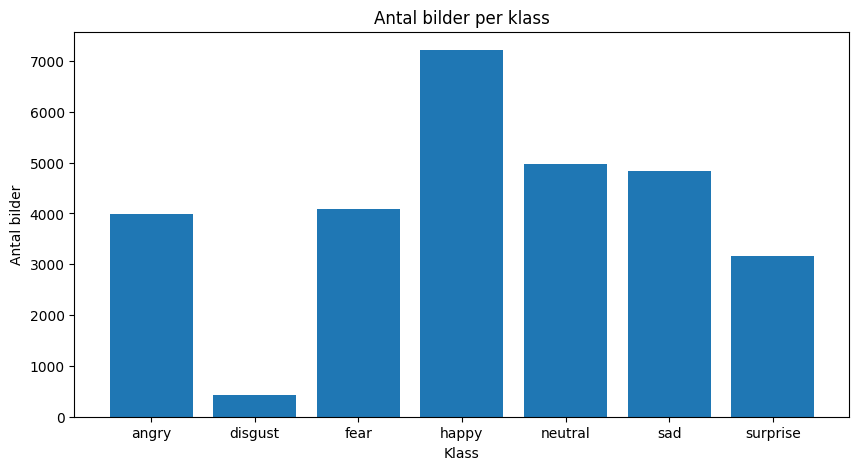

In [3]:
plt.figure(figsize=(10,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Antal bilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

plt.show()

## Resultat  
- Datasetet innehåller 7 känsloklasser.
- Vissa klasser har fler bilder än andra.
- Bilderna är gråskalebilder med låg upplösning.
- Datasetet verkar något obalanserat.
- Bilderna visar ansiktsuttryck för olika emotioner.

## Data förbredning

Målet är att göra datan användbar för en neural nätverksmodell.

In [4]:
X = []
y = []

for label , class_name in enumerate(classes):

    class_folder = os.path.join(train_path, class_name)

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_name)

        image = load_img(
            image_path,
            color_mode="grayscale",
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        image = img_to_array(image)

        X.append(image)
        y.append(label)


X = np.array(X)
y = np.array(y)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unika klass:", np.unique(y))

print("Minsta pixelvärde:", X.min())
print("Största pixelvärde:", X.max())

X shape: (28709, 48, 48, 1)
y shape: (28709,)
Unika klass: [0 1 2 3 4 5 6]
Minsta pixelvärde: 0.0
Största pixelvärde: 255.0


In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (23254, 48, 48, 1)
X_val: (2584, 48, 48, 1)
X_test: (2871, 48, 48, 1)


In [6]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


In [7]:
print("X_train shape efter kanal-dim:", X_train.shape)
print("X_val shape efter kanal-dim:", X_val.shape)
print("X_test shape efter kanal-dim:", X_test.shape)

print("Exempel på labels:", y_train[:7])

X_train shape efter kanal-dim: (23254, 48, 48, 1)
X_val shape efter kanal-dim: (2584, 48, 48, 1)
X_test shape efter kanal-dim: (2871, 48, 48, 1)
Exempel på labels: [2 5 2 4 2 3 0]


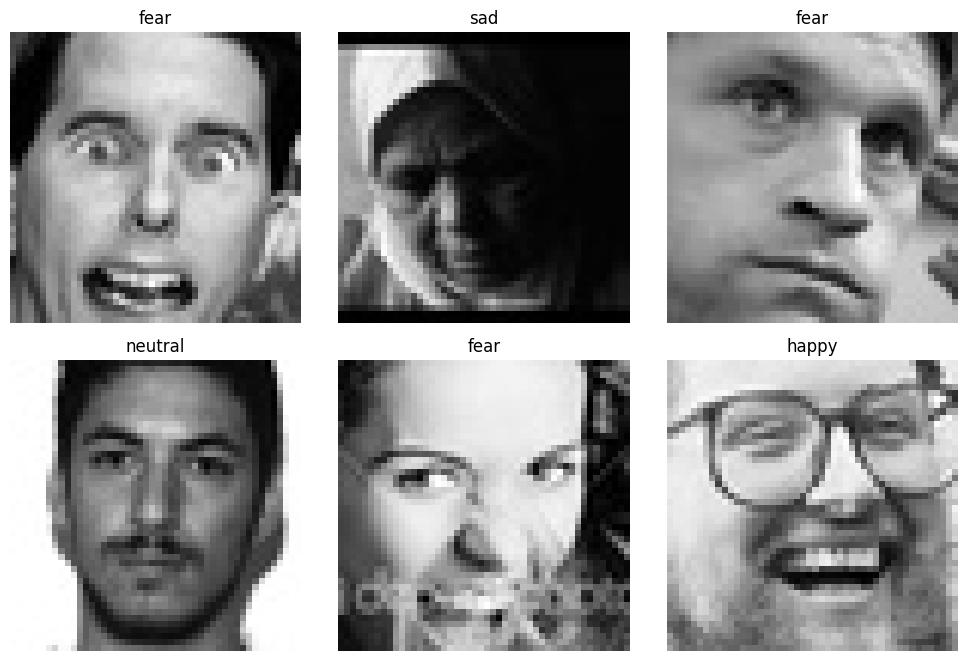

In [8]:
plt.figure(figsize=(10, 10))

for i in range(6):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_train[i].squeeze(), cmap="gray")

    plt.title(classes[y_train[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
model = keras.Sequential([

    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(len(classes), activation="softmax")
])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.2462 - loss: 1.8157 - val_accuracy: 0.2663 - val_loss: 1.7696
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.3184 - loss: 1.7135 - val_accuracy: 0.3665 - val_loss: 1.6301
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.3794 - loss: 1.6199 - val_accuracy: 0.3913 - val_loss: 1.5652
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.4060 - loss: 1.5661 - val_accuracy: 0.4222 - val_loss: 1.5181
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.4215 - loss: 1.5209 - val_accuracy: 0.4296 - val_loss: 1.4849
Epoch 6/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.4362 - loss: 1.4850 - val_accuracy: 0.4385 - val_loss: 1.4453
Epoch 7/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.4466 - loss: 1.4532 - val_accuracy: 0.4485 - val_loss: 1.4353
Epoch 8/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 44s 121ms/step - accuracy: 0.4601 - loss: 1.4215

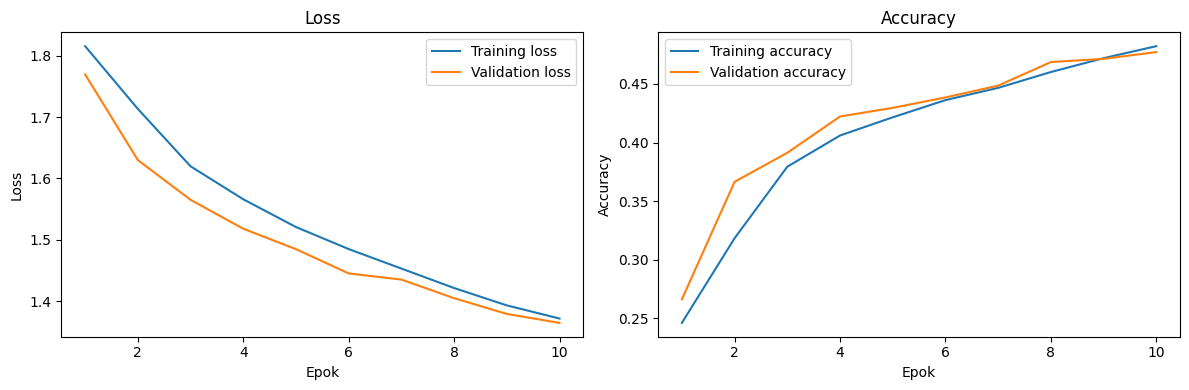

In [13]:
def plot_history(history):

    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)

    plt.plot(epochs, history_df["loss"], label="Training loss")

    plt.plot(epochs, history_df["val_loss"], label="Validation loss")

    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)

    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")

    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")

    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## Resultat 
Modellen lär sig snabbt. Den fungerar bra på vår validation data. Det finns inget tydligt gap mellan training- och validation-resultaten, vilket tyder på att modellen inte överanpassar (overfitting). Detta innebär att modellen generaliserar bra till nya, osedda data.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.3728
Test accuracy: 0.4789


Modellen uppnådde en test accuracy på cirka 47.9%, vilket innebär att den klassificerar rätt i ungefär hälften av fallen. Test loss var 1.37, vilket indikerar att modellen fortfarande har en relativt hög felmarginal. 



## Prediktioner på ny data

Bilden jag använder för prediktion är från testdatan.

In [15]:
n_images = 25

X_new = X_test[:n_images]
y_true = y_test[:n_images]

y_proba = model.predict(X_new)

y_pred = np.argmax(y_proba, axis=1)

print("Sanna labels:      ", y_true)
print("Predikterade labels:", y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
Sanna labels:       [6 0 6 3 4 4 4 3 5 3 4 2 4 6 6 2 4 4 2 5 3 6 4 2 5]
Predikterade labels: [6 5 6 3 3 4 3 3 4 5 4 4 4 5 6 0 4 4 5 4 3 5 3 2 5]


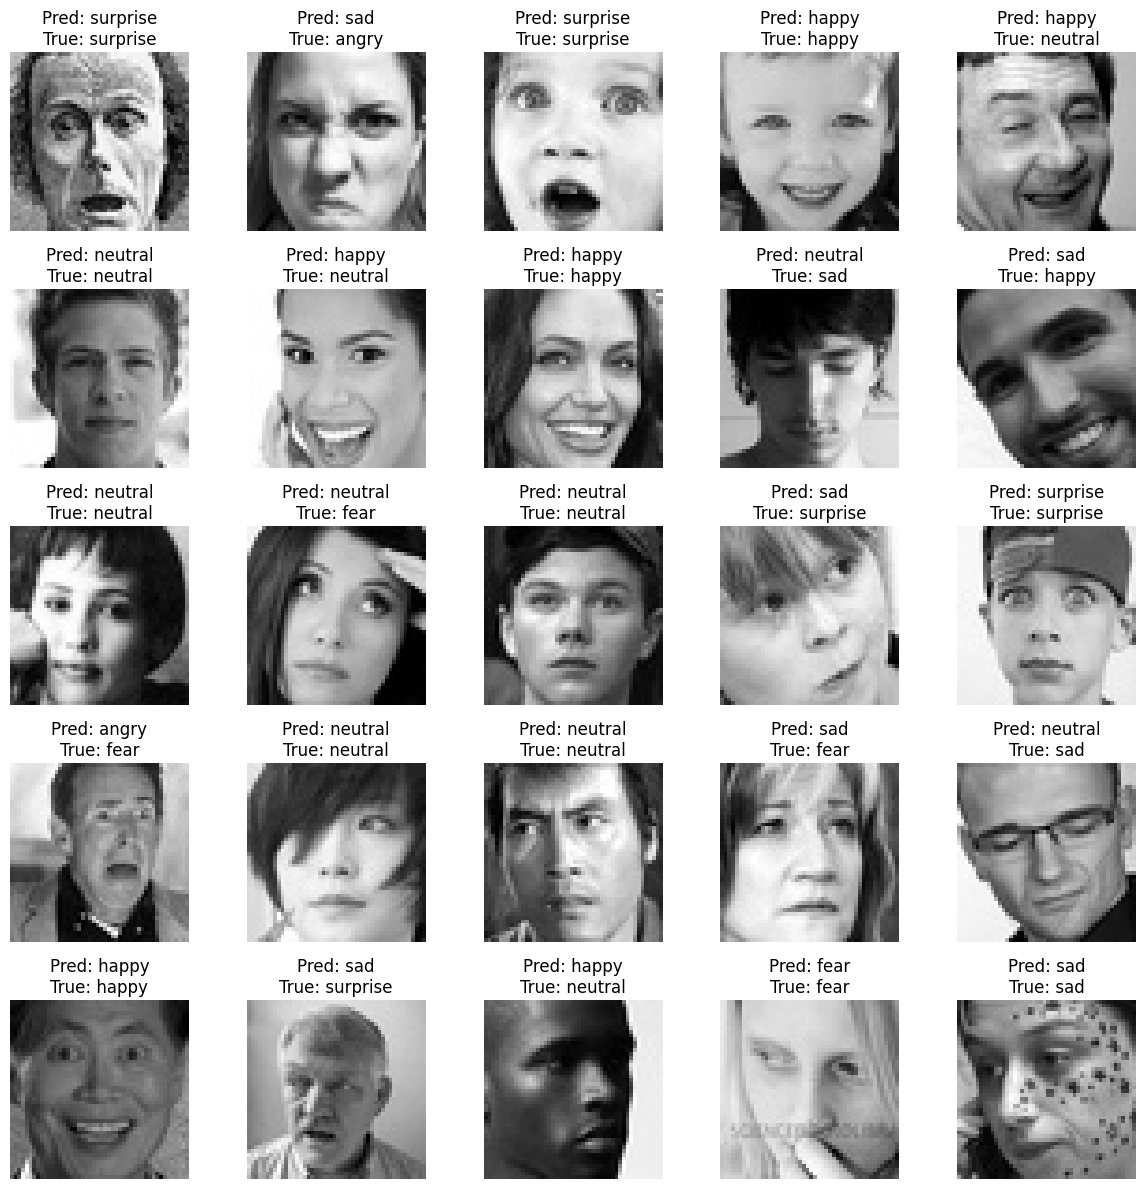

In [16]:
plt.figure(figsize=(12, 12))

for i in range(n_images):

    plt.subplot(5, 5, i + 1)

    plt.imshow(X_new[i].squeeze(), cmap="gray")

    pred_class = classes[y_pred[i]]
    true_class = classes[y_true[i]]

    plt.title(f"Pred: {pred_class}\nTrue: {true_class}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
image_index = 5

probabilities = pd.DataFrame({
    "Klass": classes,
    "Sannolikhet": y_proba[image_index]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (
    probabilities["Sannolikhet"] * 100
).round(2)

probabilities["Sannolikhet"] = (
    probabilities["Sannolikhet"]
).round(6)

print("Sann label:", classes[y_true[image_index]])
print("Predikterad label:", classes[y_pred[image_index]])

display(probabilities[["Klass", "Sannolikhet %", "Sannolikhet"]])

Sann label: neutral
Predikterad label: neutral


,Klass,Sannolikhet %,Sannolikhet
4,neutral,42.68,0.426815
0,angry,24.58,0.245809
2,fear,12.58,0.125835
5,sad,11.31,0.113084
3,happy,5.98,0.059780
6,surprise,1.62,0.016229
1,disgust,1.24,0.012448


In [18]:
model.save("fer2013_cnn_model.keras")

In [19]:
loaded_model = keras.models.load_model("fer2013_cnn_model.keras")

loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Laddad modell - test loss: {loaded_test_loss:.4f}")
print(f"Laddad modell - test accuracy: {loaded_test_accuracy:.4f}")

Laddad modell - test loss: 1.3728
Laddad modell - test accuracy: 0.4789


##  Analysera resultatet

Modellen presterar på en medelnivå med en test accuracy på cirka 47.9%, vilket visar att den har lärt sig vissa mönster men fortfarande gör många fel. Det finns inga tydliga tecken på stark overfitting, men resultaten tyder på att modellen är begränsad och har svårt att skilja mellan vissa klasser, vilket leder till underfitting eller låg modellkapacitet.

Modellen fungerar alltså, men har tydliga begränsningar i noggrannhet och generalisering.

##  Reflektion

I detta projekt var det mest utmanande att tolka resultaten och förstå modellens beteende mellan träning och testdata. Jag lärde mig hur man bygger, tränar, sparar och utvärderar en maskininlärningsmodell. Om jag gjorde om uppgiften skulle jag försöka förbättra modellen med bättre arkitektur och mer optimering. Jag bedömer att arbetet motsvarar G-nivå, eftersom alla grundkrav är uppfyllda men resultaten och optimeringen kan förbättras.